# Aprendizaje No Supervisado

## Objetivo

Comprender cómo detectar estructuras y patrones en datos **sin etiquetas** mediante técnicas de clustering y reducción de dimensionalidad.

## Contenidos del trabajo práctico

1. Diferencias entre aprendizaje supervisado y no supervisado
2. Preparación y escalado de datos para clustering
3. Algoritmo **K-Means**
4. Elbow Method y Silhouette Score para elegir el K óptimo
5. **PCA** aplicado a visualización de clusters



---
## Imports y configuración inicial

Ejecutá la siguiente celda para importar todas las librerías necesarias.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.datasets import make_blobs

import warnings
warnings.filterwarnings('ignore')

# Configuración visual
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 6)

---
## Parte 1: Supervisado vs. No Supervisado

### Conceptos teóricos

| Característica | Aprendizaje Supervisado | Aprendizaje No Supervisado |
|---|---|---|
| **Etiquetas (y)** | Sí, disponibles | No, no existen |
| **Objetivo** | Predecir una variable target | Descubrir estructura oculta |
| **Ejemplos de algoritmos** | Regresión Lineal, Random Forest | K-Means, DBSCAN, PCA |
| **Validación** | Métricas comparables (accuracy, RMSE) | Métricas internas (silhouette, inercia) |
| **Casos de uso** | Clasificación de spam, predicción de precio | Segmentación de clientes, detección de anomalías |

### Ejercicio 1.1 – Reflexión conceptual

Respondé con tus propias palabras:

**a)** ¿Por qué en el aprendizaje no supervisado es más difícil saber si el modelo "funcionó bien"?

> _Escribí tu respuesta aquí_

**b)** Mencioná dos casos de uso reales donde no sería posible usar aprendizaje supervisado y explicá por qué.

> _Escribí tu respuesta aquí_

---
## Parte 2: Dataset – Segmentación de Clientes

Vamos a trabajar con un dataset simulado de clientes de un e-commerce con las siguientes variables:

- `edad`: edad del cliente
- `ingreso_anual`: ingreso anual estimado (en miles de $)

- `gasto_mensual`: gasto mensual promedio en la plataforma (en $)
- `frecuencia_compras`: cantidad de compras en el último año
- `antiguedad_meses`: meses que lleva siendo cliente

### Carga del dataset

In [2]:
np.random.seed(42)
n = 300

# Generamos 3 grupos de clientes con perfiles distintos
grupo_1 = pd.DataFrame({
    'edad': np.random.normal(25, 4, 100).astype(int),
    'ingreso_anual': np.random.normal(30, 5, 100),
    'gasto_mensual': np.random.normal(80, 15, 100),
    'frecuencia_compras': np.random.normal(5, 2, 100).astype(int),
    'antiguedad_meses': np.random.normal(12, 4, 100).astype(int)
})

grupo_2 = pd.DataFrame({
    'edad': np.random.normal(40, 5, 100).astype(int),
    'ingreso_anual': np.random.normal(70, 10, 100),
    'gasto_mensual': np.random.normal(250, 40, 100),
    'frecuencia_compras': np.random.normal(15, 3, 100).astype(int),
    'antiguedad_meses': np.random.normal(36, 8, 100).astype(int)
})

grupo_3 = pd.DataFrame({
    'edad': np.random.normal(55, 6, 100).astype(int),
    'ingreso_anual': np.random.normal(55, 8, 100),
    'gasto_mensual': np.random.normal(150, 25, 100),
    'frecuencia_compras': np.random.normal(8, 2, 100).astype(int),
    'antiguedad_meses': np.random.normal(60, 12, 100).astype(int)
})

df = pd.concat([grupo_1, grupo_2, grupo_3], ignore_index=True)
df = df.clip(lower=0)  # evitar valores negativos

print(f'Shape del dataset: {df.shape}')
df.head(10)

Shape del dataset: (300, 5)


,edad,ingreso_anual,gasto_mensual,frecuencia_compras,antiguedad_meses
0,26,22.923146,85.366810,3,5
1,24,27.896773,88.411768,3,9
2,27,28.286427,96.245769,6,12
3,31,25.988614,95.807031,6,12
4,24,29.193571,59.334959,4,10
5,24,32.020254,65.932624,5,14
6,31,39.430930,87.725529,7,7
7,28,30.872889,87.706789,3,11
8,23,31.287752,87.725715,6,12
9,27,29.627770,137.790972,4,14


### Ejercicio 2.1 – Exploración inicial

In [3]:
# TODO: Mostrá las estadísticas descriptivas básicas del dataset
# Probá df.describe().T.round(2)
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
edad,300.0,39.50,13.67,14.00,26.00,38.50,52.00,67.00
ingreso_anual,300.0,52.07,18.65,20.41,32.56,54.91,66.59,95.73
gasto_mensual,300.0,160.62,74.88,31.38,91.11,151.06,221.18,355.30
frecuencia_compras,300.0,9.11,4.97,0.00,5.00,8.00,13.00,22.00
antiguedad_meses,300.0,36.55,22.74,2.00,14.00,36.00,53.25,91.00


In [4]:
# TODO: Verificá si hay valores nulos
df.isnull().sum()

edad                  0
ingreso_anual         0
gasto_mensual         0
frecuencia_compras    0
antiguedad_meses      0
dtype: int64

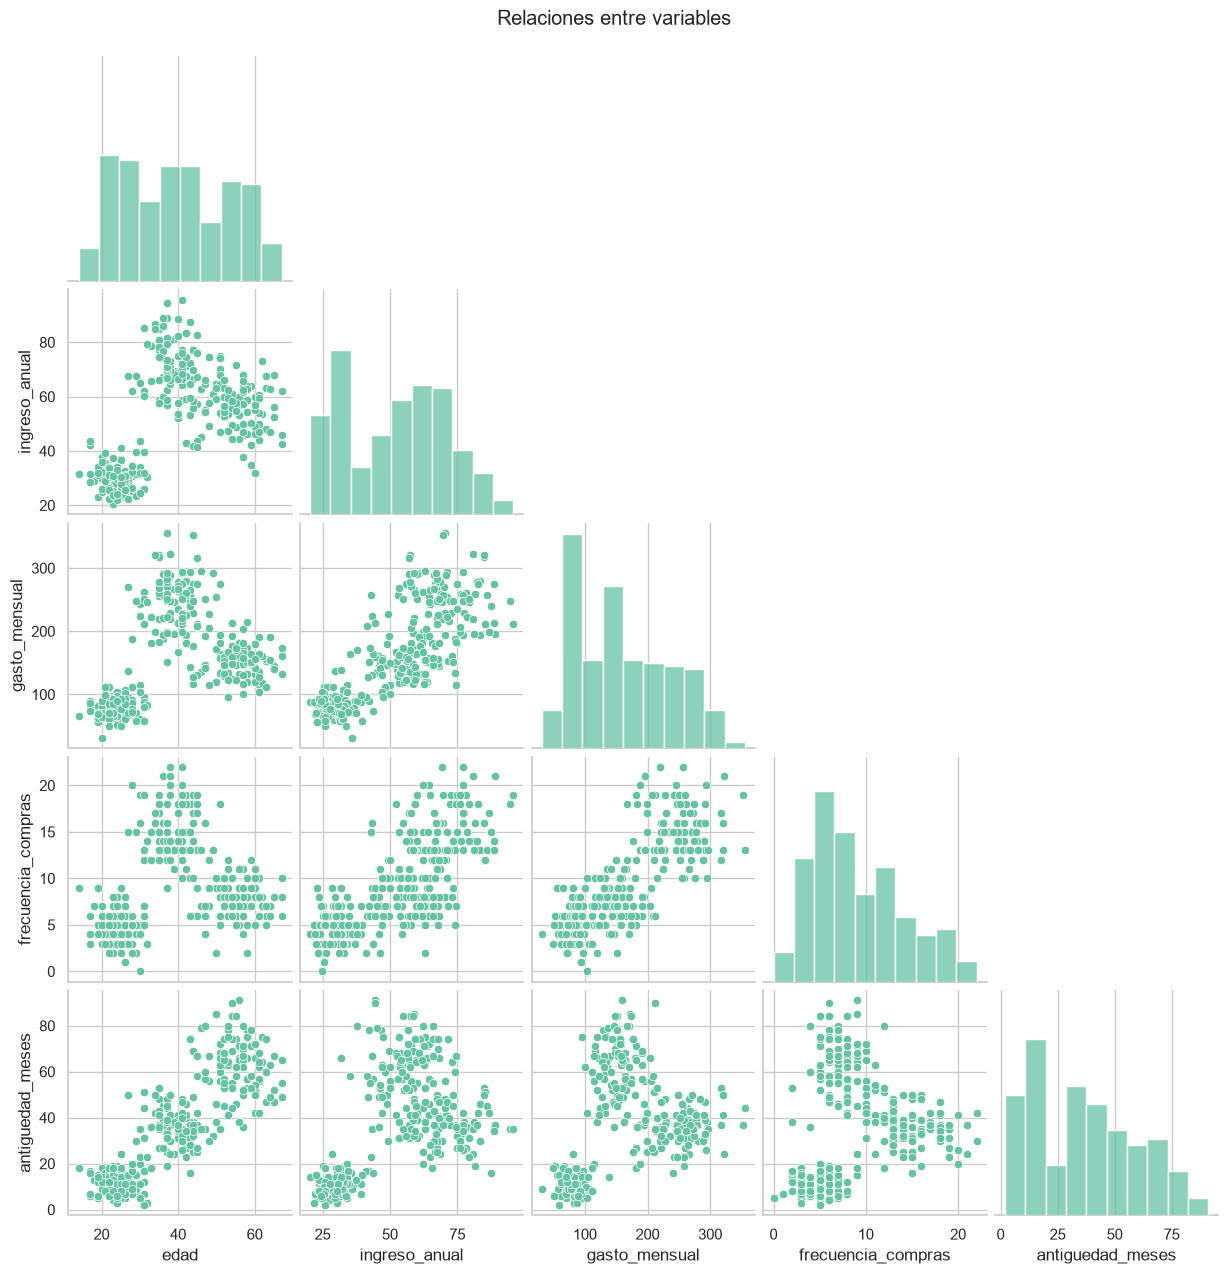

In [5]:
# TODO: Generá un pairplot para visualizar las relaciones entre variables
# La diagonal muestra distribuciones; el resto, relaciones entre pares.
sns.pairplot(df, corner=True, diag_kind='hist')
plt.suptitle('Relaciones entre variables', y=1.02)
plt.show()

---
## Parte 3: Escalado de datos

El clustering es sensible a la escala de las variables. Antes de aplicar K-Means, debemos **estandarizar** los datos.

### ¿Por qué escalar?

K-Means calcula distancias euclidianas. Si `ingreso_anual` tiene valores en el rango 20–90 y `frecuencia_compras` en el rango 1–25, la variable de mayor escala domina el cálculo y **distorsiona los clusters**.

In [6]:
# Escalado con StandardScaler
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns, index=df.index)
X_scaled.describe().round(2)

,edad,ingreso_anual,gasto_mensual,frecuencia_compras,antiguedad_meses
count,300.00,300.00,300.00,300.00,300.00
mean,-0.00,0.00,-0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00
min,-1.87,-1.70,-1.73,-1.83,-1.52
25%,-0.99,-1.05,-0.93,-0.83,-0.99
50%,-0.07,0.15,-0.13,-0.22,-0.02
75%,0.92,0.78,0.81,0.78,0.74
max,2.02,2.35,2.60,2.60,2.40


### Ejercicio 3.1 – Comparación antes y después del escalado

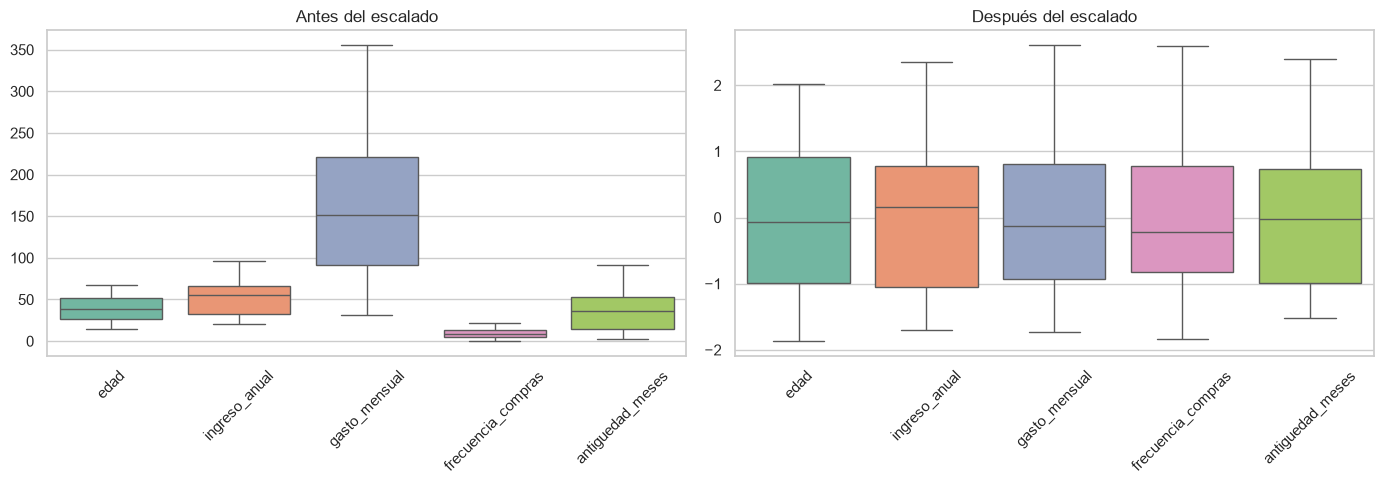

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, ax=axes[0])
axes[0].set_title('Antes del escalado')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=X_scaled, ax=axes[1])
axes[1].set_title('Después del escalado')
axes[1].tick_params(axis='x', rotation=45)

# StandardScaler produce media ≈ 0 y desvío ≈ 1
plt.tight_layout(); plt.show()

---
## Parte 4: Algoritmo K-Means

### ¿Cómo funciona K-Means?

1. Se eligen **K centroides** aleatoriamente
2. Cada punto se asigna al centroide más cercano → se forman K clusters
3. Se recalculan los centroides como la **media** de los puntos asignados
4. Se repiten los pasos 2 y 3 hasta que los centroides no cambian (convergencia)

**Inercia** (Within-Cluster Sum of Squares – WCSS): suma de las distancias al cuadrado de cada punto a su centroide. A menor inercia → clusters más compactos.


### Aplicando K-Means con K=3

In [8]:
# Entrenamos K-Means con K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10, init='k-means++')
kmeans.fit(X_scaled)

# Asignamos las etiquetas de cluster al dataframe original
df['cluster'] = kmeans.labels_
X_scaled['cluster'] = kmeans.labels_

print(f'Inercia (WCSS) con K=3: {kmeans.inertia_:.2f}')

Inercia (WCSS) con K=3: 244.55


Al haber aplicado StandardScaler, la varianza total teórica de los datos es aproximadamente $N \times \text{variables} = 300 \times 5 = 1500$.
Pasar de una varianza total original de 1500 a una inercia intracluster de 244.55 con $K = 3$ significa que el modelo logró explicar y reducir aproximadamente el 83.7% de la varianza total del conjunto de datos.


Ejercicio 4.1 – Perfil de cada cluster

Calculá el promedio de cada variable por cluster e interpretá qué tipo de cliente representa cada grupo.

In [9]:
# TODO: Calculá df.groupby('cluster').mean().round(2)
# Guardalo en una variable llamada 'perfil_clusters'
perfil_clusters = df.groupby('cluster').mean().round(2)
perfil_clusters

,edad,ingreso_anual,gasto_mensual,frecuencia_compras,antiguedad_meses
cluster,,,,,
0,55.66,55.68,151.13,7.44,62.86
1,24.14,30.11,80.97,4.69,11.27
2,38.86,70.27,248.78,15.11,35.79


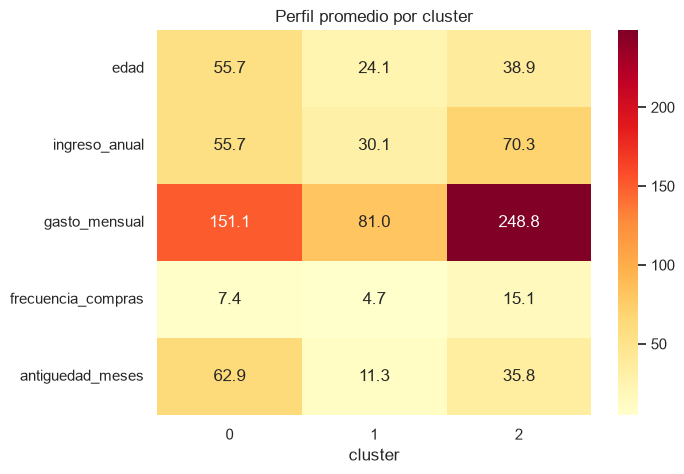

In [10]:
# TODO: Visualizá el perfil con un heatmap usando sns.heatmap()
# Usá perfil_clusters.T, annot=True, fmt='.1f', cmap='YlOrRd'
# Título: 'Perfil promedio por cluster'
plt.figure(figsize=(7, 5))
sns.heatmap(perfil_clusters.T, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('Perfil promedio por cluster')
plt.show()

**¿Qué tipo de cliente representa cada cluster?**

| Cluster | Descripción |
|---------|-------------|
| 0 | **Maduros y leales**: edad promedio ~56 años, antigüedad muy alta (~63 meses), gasto e ingreso medios, frecuencia de compra moderada. |
| 1 | **Jóvenes de bajo consumo**: los más jóvenes (~24 años), menor ingreso y gasto del grupo, poca antigüedad (~11 meses) — clientes recién llegados. |
| 2 | **Premium / alto valor**: mayor ingreso y gasto de los tres grupos, la frecuencia de compra más alta (~15/año), antigüedad intermedia (~36 meses). |</cell id="u1v2w3x4">


---
## Parte 5: Elbow Method y Silhouette Score

### El problema de elegir K

No siempre sabemos cuántos grupos tiene el dataset. Usamos dos métodos para encontrar el K óptimo:

- **Elbow Method**: graficamos la inercia para distintos valores de K. El codo sugiere un valor razonable de K, aunque puede no ser claramente visible.
- **Silhouette Score**: mide qué tan bien asignado está cada punto (rango: -1 a 1). Un valor cercano a 1 indica que el punto está bien asignado a su cluster.


### Graficamos el codo (Elbow Method)

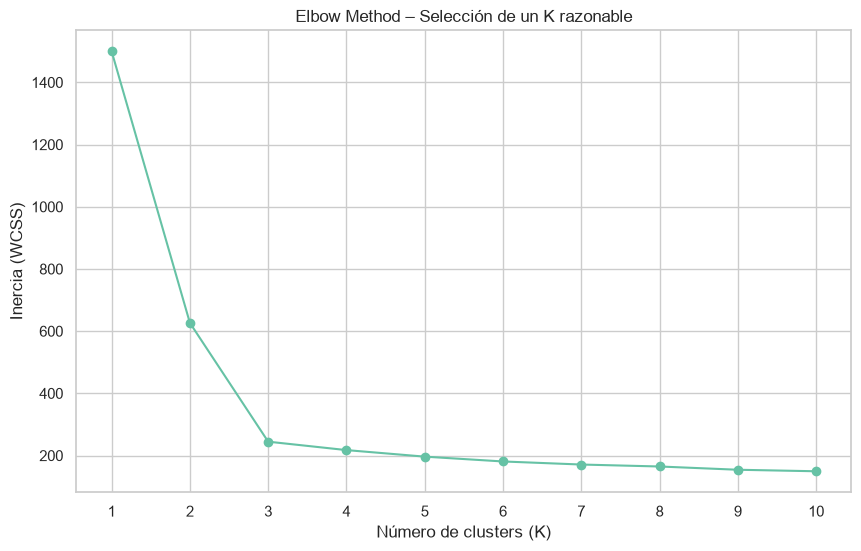

In [11]:
# Para Elbow incluimos K=1, que sirve como punto inicial de comparación.
inercias = []
k_range_elbow = range(1, 11)
X_modelo = X_scaled.drop('cluster', axis=1)

for k in k_range_elbow:
    modelo_k = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo_k.fit(X_modelo)
    inercias.append(modelo_k.inertia_)

plt.plot(list(k_range_elbow), inercias, 'o-')
plt.title('Elbow Method – Selección de un K razonable')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Inercia (WCSS)')
plt.xticks(list(k_range_elbow))
plt.show()

# La inercia siempre disminuye al aumentar K. Buscamos el punto a partir del
# cual agregar clusters produce mejoras cada vez menores.

### Implementar Silhouette Score

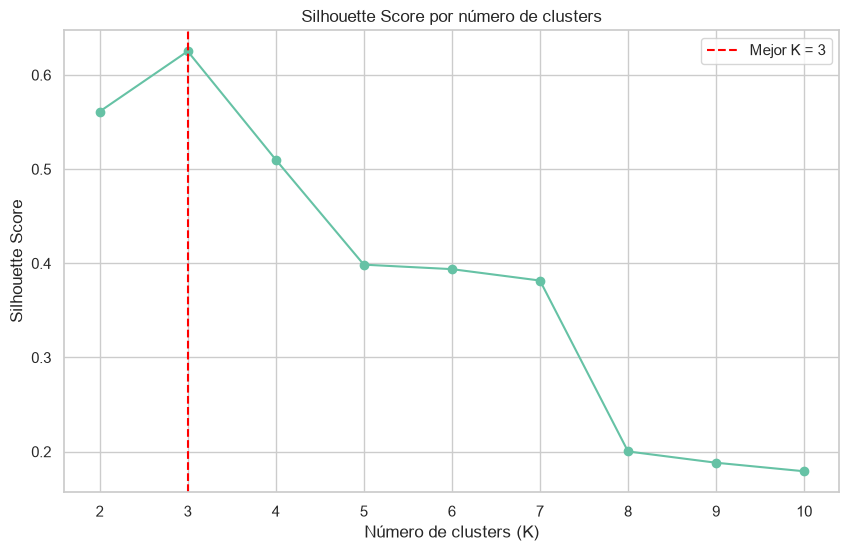

Mejor score: 0.625 para K = 3


In [12]:
# El Silhouette Score no está definido para K=1 (no hay cluster vecino con quien comparar),
# así que lo calculamos a partir de K=2.
k_range_silhouette = range(2, 11)

silhouette_scores = []
for k in k_range_silhouette:
    modelo_k = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = modelo_k.fit_predict(X_modelo)
    silhouette_scores.append(silhouette_score(X_modelo, labels_k))

mejor_i = int(np.argmax(silhouette_scores))
mejor_k = list(k_range_silhouette)[mejor_i]
mejor_score = silhouette_scores[mejor_i]

plt.plot(list(k_range_silhouette), silhouette_scores, 'o-')
plt.axvline(mejor_k, color='red', linestyle='--', label=f'Mejor K = {mejor_k}')
plt.title('Silhouette Score por número de clusters')
plt.xlabel('Número de clusters (K)'); plt.ylabel('Silhouette Score')
plt.xticks(list(k_range_silhouette)); plt.legend(); plt.show()
print(f'Mejor score: {mejor_score:.3f} para K = {mejor_k}')

**Conclusión:**

- El Elbow Method sugiere K = 3 (la inercia cae de 626 a 244 al pasar de K=2 a K=3, y a partir de ahí la mejora por cada K adicional es mucho menor: 244 → 217 → 196 → ...).
- El Silhouette Score más alto es 0.625 para K = 3.

Ambos métodos coinciden en K=3, que además es el mismo K que usamos en la Parte 4 — tiene sentido, porque el dataset se generó a propósito con 3 grupos de clientes distintos.

### Clasificación de un nuevo cliente

In [13]:
# Creamos un nuevo cliente
# Ojo: las columnas y la escala tienen que coincidir EXACTAMENTE con las que
# usamos para entrenar el scaler (df): 'ingreso_anual' y 'gasto_mensual' están
# en las mismas unidades que el dataset original (miles de $ y $ respectivamente,
# no 65000/18000), y los nombres deben ser idénticos a los de df.
nuevo_cliente = pd.DataFrame([{
    'edad': 35,
    'ingreso_anual': 65,
    'gasto_mensual': 180,
    'frecuencia_compras': 12,
    'antiguedad_meses': 4
}])

nuevo_cliente

,edad,ingreso_anual,gasto_mensual,frecuencia_compras,antiguedad_meses
0,35,65,180,12,4


In [14]:
# Aplicamos el scaler que ya fue ajustado con los clientes originales
nuevo_cliente_scaled = scaler.transform(nuevo_cliente)

nuevo_cliente_scaled

array([[-0.32951384,  0.69451222,  0.25921024,  0.5826191 , -1.43382216]])

In [15]:
cluster_nuevo = kmeans.predict(nuevo_cliente_scaled)

print("El nuevo cliente pertenece al cluster:", cluster_nuevo[0])

El nuevo cliente pertenece al cluster: 2


In [16]:
# veamos las distancias a cada centroide
distancias = kmeans.transform(nuevo_cliente_scaled)

print("Distancia a cada centroide:")
print(distancias)

Distancia a cada centroide:
[[3.20228764 2.85815388 1.8330372 ]]


---
## Parte 6: PCA aplicado a visualización de clusters

Nuestro dataset tiene 5 dimensiones. Para visualizar los clusters en 2D, usamos **PCA** (Análisis de Componentes Principales), que reduce las dimensiones preservando la mayor varianza posible.

### ¿Qué es PCA?

PCA encuentra nuevas variables (componentes principales) que son **combinaciones lineales** de las originales, ordenadas por la cantidad de varianza que explican. Las primeras dos componentes nos permiten proyectar el dataset en un plano 2D.

In [17]:
# Aplicamos PCA a 2 componentes
X_sin_cluster = X_scaled.drop('cluster', axis=1)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sin_cluster)

varianza_explicada = pca.explained_variance_ratio_
print(f'Varianza explicada por PC1: {varianza_explicada[0]:.2%}')
print(f'Varianza explicada por PC2: {varianza_explicada[1]:.2%}')
print(f'Varianza total explicada: {sum(varianza_explicada):.2%}')

Varianza explicada por PC1: 62.46%
Varianza explicada por PC2: 27.32%
Varianza total explicada: 89.78%




```
# Tiene formato de código
```

### Visualizar clusters con PCA

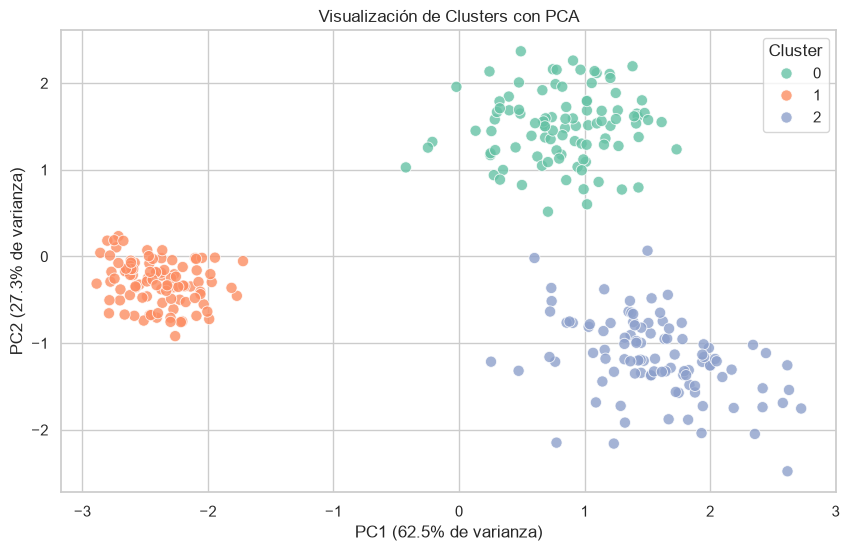

In [18]:
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['cluster'] = df['cluster'].to_numpy()

sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='cluster',
                palette='Set2', s=65, alpha=0.8)
plt.title('Visualización de Clusters con PCA')
plt.xlabel(f'PC1 ({varianza_explicada[0]:.1%} de varianza)')
plt.ylabel(f'PC2 ({varianza_explicada[1]:.1%} de varianza)')
plt.legend(title='Cluster'); plt.show()

# PCA solo proyecta para visualizar; K-Means usó las cinco variables escaladas.


### Loadings de PCA - Variables que contribuyen más

Los **loadings** muestran qué variables contribuyen más a cada componente principal.

Loadings de PCA:
                      PC1    PC2
edad                0.392  0.566
ingreso_anual       0.517 -0.150
gasto_mensual       0.484 -0.329
frecuencia_compras  0.430 -0.485
antiguedad_meses    0.399  0.560


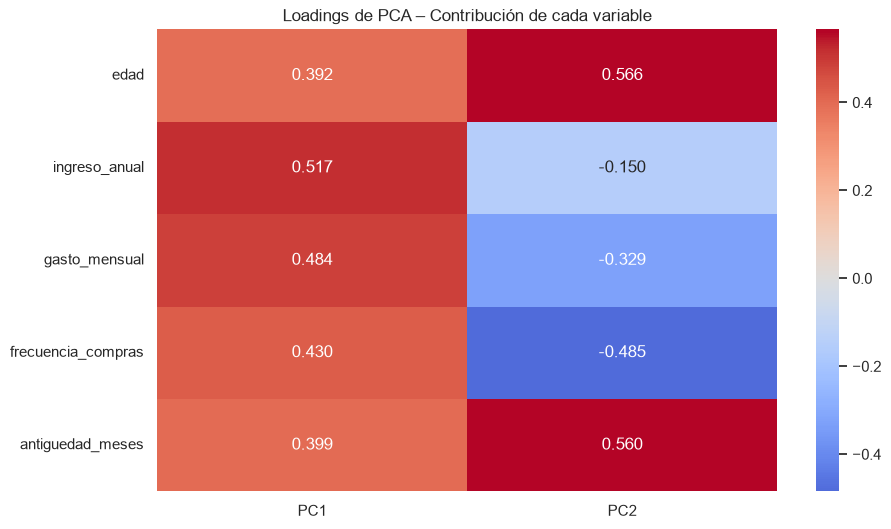

In [19]:
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'],
                        index=X_sin_cluster.columns)
print('Loadings de PCA:')
print(loadings.round(3))

sns.heatmap(loadings, annot=True, fmt='.3f', cmap='coolwarm', center=0)
plt.title('Loadings de PCA – Contribución de cada variable')
plt.show()


**Interpretación:**

- PC1 (62.5% de la varianza) está influenciada de forma pareja y positiva por **todas** las variables (ingreso_anual 0.52, gasto_mensual 0.48, frecuencia_compras 0.43, antiguedad_meses 0.40, edad 0.39). Funciona como un eje general de "valor/intensidad del cliente": a mayor PC1, más alto es el ingreso, el gasto y la frecuencia de compra en conjunto.
- PC2 (27.3% de la varianza) contrapone edad y antigüedad (cargas positivas: 0.57 y 0.56) contra gasto_mensual y frecuencia_compras (cargas negativas: -0.33 y -0.49). Es decir, separa a los clientes "grandes en edad/antigüedad" de los clientes "grandes en gasto/frecuencia" — coherente con que el cluster 0 (maduros) y el cluster 2 (premium) queden en extremos opuestos de este eje.

## Parte 7: Ejercicio integrador

Trabajaremos con un dataset simulado de comportamiento de usuarios de una plataforma de streaming. Los datos contienen perfiles con cierta variabilidad y solapamiento, como ocurriría en un caso real.

Tu tarea es aplicar el pipeline completo de clustering **desde cero**:

1. Explorar y describir el dataset.
2. Preparar y escalar las variables.
3. Comparar distintos valores de K con Elbow y Silhouette.
4. Elegir K justificando la decisión.
5. Entrenar el modelo final.
6. Interpretar y nombrar los grupos.
7. Visualizar la solución mediante PCA.
8. Evaluar si la segmentación sería útil para tomar decisiones.

> El objetivo no es solamente ejecutar código, sino construir una conclusión respaldada por evidencias.


In [20]:
# Dataset simulado de usuarios de streaming
rng = np.random.default_rng(42)

def generar_perfil(n, horas, generos, dias, peliculas, series, busquedas):
    # El factor de intensidad genera relaciones moderadas entre las variables.
    intensidad = rng.normal(0, 1, n)

    return pd.DataFrame({
        'horas_por_semana': rng.normal(horas, 1.8, n) + 0.6 * intensidad,
        'generos_distintos': rng.normal(generos, 0.8, n) + 0.1 * intensidad,
        'dias_activo_mes': rng.normal(dias, 2.5, n) + 0.6 * intensidad,
        'peliculas_completadas': rng.normal(peliculas, 1.6, n) + 0.3 * intensidad,
        'series_completadas': rng.normal(series, 1.5, n) + 0.3 * intensidad,
        'busquedas_semana': rng.normal(busquedas, 1.7, n) + 0.2 * intensidad
    })

# Los nombres de los perfiles se usan únicamente para simular datos.
# No se incorporan como etiquetas al dataset que recibirá el algoritmo.
usuarios_ocasionales = generar_perfil(140, 4, 3, 7, 2, 1, 3)
usuarios_peliculas = generar_perfil(130, 11, 6, 16, 9, 3, 8)
usuarios_series = generar_perfil(130, 16, 4, 22, 3, 9, 5)

df_streaming = pd.concat(
    [usuarios_ocasionales, usuarios_peliculas, usuarios_series],
    ignore_index=True
)

# Ajustamos límites posibles y tipos de datos.
df_streaming['horas_por_semana'] = df_streaming['horas_por_semana'].clip(0, 35).round(2)
df_streaming['generos_distintos'] = df_streaming['generos_distintos'].clip(1, 12).round().astype(int)
df_streaming['dias_activo_mes'] = df_streaming['dias_activo_mes'].clip(1, 30).round().astype(int)
df_streaming['peliculas_completadas'] = df_streaming['peliculas_completadas'].clip(0, 20).round().astype(int)
df_streaming['series_completadas'] = df_streaming['series_completadas'].clip(0, 20).round().astype(int)
df_streaming['busquedas_semana'] = df_streaming['busquedas_semana'].clip(0, 20).round(2)

# Mezclamos las filas para que los perfiles originales no queden ordenados.
df_streaming = df_streaming.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Shape: {df_streaming.shape}')
df_streaming.head()

Shape: (400, 6)


,horas_por_semana,generos_distintos,dias_activo_mes,peliculas_completadas,series_completadas,busquedas_semana
0,12.01,6,19,7,3,7.70
1,18.02,4,23,0,6,6.98
2,1.31,3,12,0,0,2.94
3,7.88,5,14,9,1,9.02
4,6.12,4,7,0,2,5.78


                       count   mean   std  min   25%    50%    75%    max
horas_por_semana       400.0  10.09  5.30  0.0  4.87  10.66  14.69  21.82
generos_distintos      400.0   4.28  1.55  1.0  3.00   4.00   6.00   8.00
dias_activo_mes        400.0  14.82  6.85  1.0  8.00  16.00  21.00  28.00
peliculas_completadas  400.0   4.54  3.44  0.0  2.00   4.00   8.00  14.00
series_completadas     400.0   4.26  3.61  0.0  1.00   3.00   8.00  13.00
busquedas_semana       400.0   5.22  2.60  0.0  3.29   5.03   7.21  12.68

Valores nulos:
horas_por_semana         0
generos_distintos        0
dias_activo_mes          0
peliculas_completadas    0
series_completadas       0
busquedas_semana         0
dtype: int64


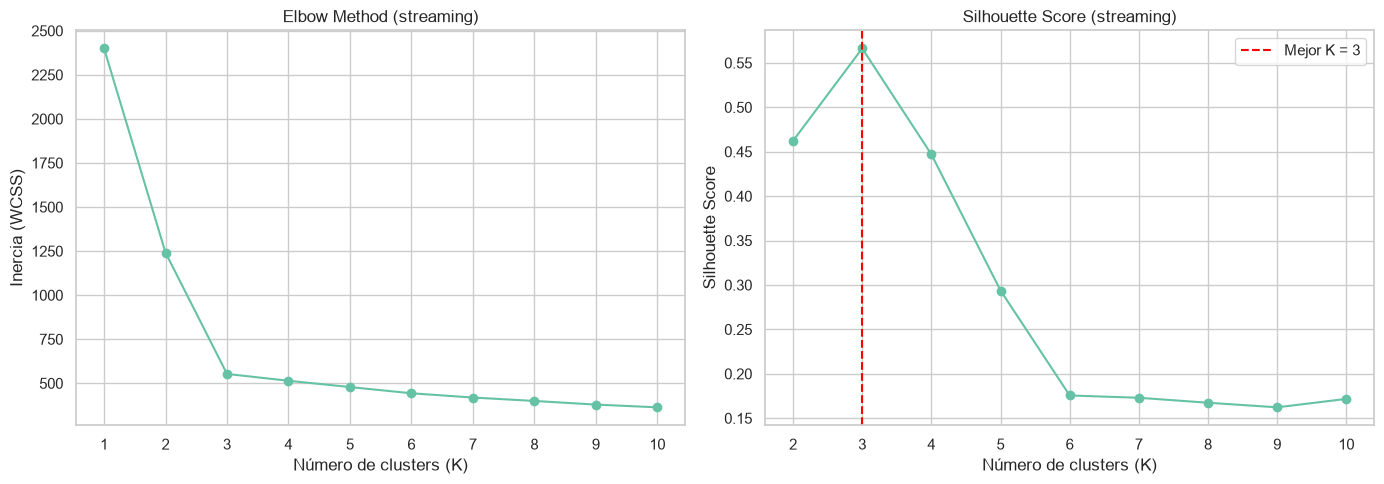

Mejor Silhouette Score: 0.566 para K = 3
K elegido: 3  |  Inercia: 552.97
cluster
0    130
1    140
2    130
Name: count, dtype: int64


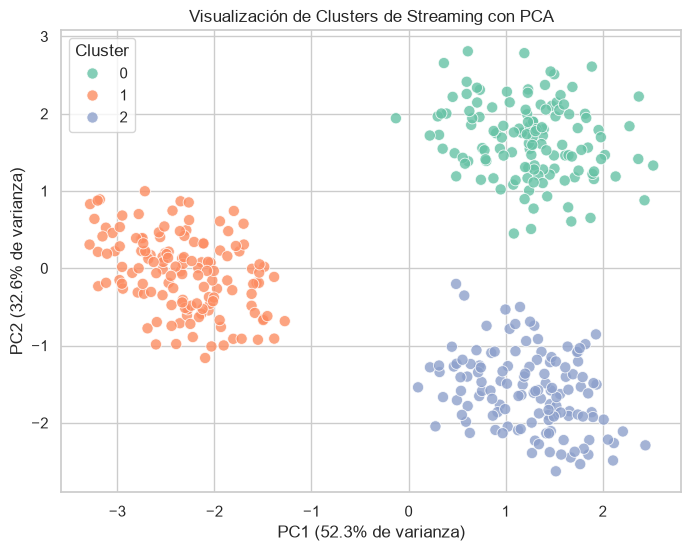

Varianza total explicada por PC1+PC2: 84.9%
Perfil promedio por cluster:
         horas_por_semana  generos_distintos  dias_activo_mes  \
cluster                                                         
0                   15.92               3.86            22.11   
1                    3.94               3.01             6.88   
2                   10.89               6.05            16.10   

         peliculas_completadas  series_completadas  busquedas_semana  
cluster                                                               
0                         3.05                8.96              5.03  
1                         1.94                1.24              2.98  
2                         8.83                2.80              7.83  


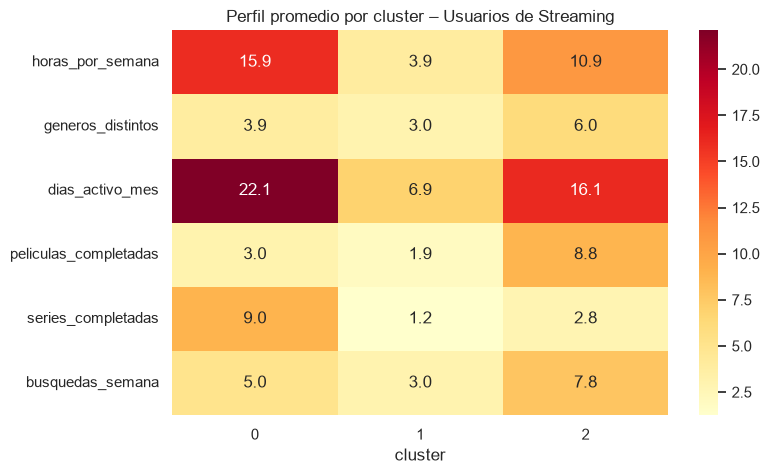

Umbral de anomalía (media + 2 desvíos): 1.80
Usuarios atípicos detectados: 8 de 400


,horas_por_semana,generos_distintos,dias_activo_mes,peliculas_completadas,series_completadas,busquedas_semana,cluster,distancia_centroide
162,15.19,6,28,6,6,2.02,0,2.327143
139,12.13,4,22,2,7,0.00,0,2.160712
150,2.97,3,9,2,0,8.43,1,2.158543
382,8.93,5,19,9,3,12.68,2,2.066811
319,11.59,7,9,9,7,10.76,2,2.023920
256,4.39,1,7,1,0,6.66,1,1.973673
160,16.58,3,21,2,9,9.56,0,1.868092
52,14.70,3,26,4,10,9.12,0,1.823755


In [21]:
# TODO: Aplicá el pipeline completo:
# 1. Explorá el dataset (describe + nulos)
# 2. Escalá los datos con StandardScaler
# 3. Usá Elbow Method y Silhouette Score para elegir K
# 4. Entrenás K-Means con el K elegido
# 5. Visualizá los clusters con PCA
# 6. Interpretá los clusters (perfil promedio por grupo)
# 7. Detectá anomalías y describí su perfil

# --- Paso 1: Exploración ---
print(df_streaming.describe().T.round(2))
print()
print('Valores nulos:')
print(df_streaming.isnull().sum())

# --- Paso 2: Escalado ---
scaler_streaming = StandardScaler()
X_streaming_scaled = pd.DataFrame(
    scaler_streaming.fit_transform(df_streaming),
    columns=df_streaming.columns,
    index=df_streaming.index
)

# --- Paso 3: K óptimo (Elbow + Silhouette) ---
k_range_elbow_streaming = range(1, 11)
inercias_streaming = []
for k in k_range_elbow_streaming:
    modelo_k = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo_k.fit(X_streaming_scaled)
    inercias_streaming.append(modelo_k.inertia_)

k_range_silhouette_streaming = range(2, 11)
silhouette_scores_streaming = []
for k in k_range_silhouette_streaming:
    modelo_k = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = modelo_k.fit_predict(X_streaming_scaled)
    silhouette_scores_streaming.append(silhouette_score(X_streaming_scaled, labels_k))

mejor_i_streaming = int(np.argmax(silhouette_scores_streaming))
mejor_k_streaming = list(k_range_silhouette_streaming)[mejor_i_streaming]
mejor_score_streaming = silhouette_scores_streaming[mejor_i_streaming]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range_elbow_streaming), inercias_streaming, 'o-')
axes[0].set_title('Elbow Method (streaming)')
axes[0].set_xlabel('Número de clusters (K)'); axes[0].set_ylabel('Inercia (WCSS)')
axes[0].set_xticks(list(k_range_elbow_streaming))

axes[1].plot(list(k_range_silhouette_streaming), silhouette_scores_streaming, 'o-')
axes[1].axvline(mejor_k_streaming, color='red', linestyle='--', label=f'Mejor K = {mejor_k_streaming}')
axes[1].set_title('Silhouette Score (streaming)')
axes[1].set_xlabel('Número de clusters (K)'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(k_range_silhouette_streaming)); axes[1].legend()
plt.tight_layout(); plt.show()

print(f'Mejor Silhouette Score: {mejor_score_streaming:.3f} para K = {mejor_k_streaming}')

# --- Paso 4: K-Means ---
# Elegimos K en base al Silhouette Score (más objetivo que el codo cuando no es
# claramente visible), que en este caso coincide con el punto donde el Elbow
# empieza a aplanarse.
K_ELEGIDO = mejor_k_streaming
kmeans_streaming = KMeans(n_clusters=K_ELEGIDO, random_state=42, n_init=10, init='k-means++')
kmeans_streaming.fit(X_streaming_scaled)

df_streaming['cluster'] = kmeans_streaming.labels_
X_streaming_scaled['cluster'] = kmeans_streaming.labels_

print(f'K elegido: {K_ELEGIDO}  |  Inercia: {kmeans_streaming.inertia_:.2f}')
print(df_streaming['cluster'].value_counts().sort_index())

# --- Paso 5: PCA ---
X_streaming_sin_cluster = X_streaming_scaled.drop('cluster', axis=1)

pca_streaming = PCA(n_components=2, random_state=42)
X_streaming_pca = pca_streaming.fit_transform(X_streaming_sin_cluster)
varianza_explicada_streaming = pca_streaming.explained_variance_ratio_

df_streaming_pca = pd.DataFrame(X_streaming_pca, columns=['PC1', 'PC2'])
df_streaming_pca['cluster'] = df_streaming['cluster'].to_numpy()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_streaming_pca, x='PC1', y='PC2', hue='cluster',
                palette='Set2', s=65, alpha=0.8)
plt.title('Visualización de Clusters de Streaming con PCA')
plt.xlabel(f'PC1 ({varianza_explicada_streaming[0]:.1%} de varianza)')
plt.ylabel(f'PC2 ({varianza_explicada_streaming[1]:.1%} de varianza)')
plt.legend(title='Cluster'); plt.show()

print(f'Varianza total explicada por PC1+PC2: {varianza_explicada_streaming.sum():.1%}')

# --- Paso 6: Interpretación ---
perfil_streaming = df_streaming.groupby('cluster').mean().round(2)
print('Perfil promedio por cluster:')
print(perfil_streaming)

plt.figure(figsize=(8, 5))
sns.heatmap(perfil_streaming.T, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('Perfil promedio por cluster – Usuarios de Streaming')
plt.show()

# --- Paso 7: Detección de anomalías ---
# Usamos la distancia de cada punto a su propio centroide (kmeans.transform)
# como medida de "qué tan atípico" es dentro de su cluster asignado.
distancias_todas = kmeans_streaming.transform(X_streaming_sin_cluster)
distancia_al_centroide = distancias_todas[np.arange(len(df_streaming)), kmeans_streaming.labels_]
df_streaming['distancia_centroide'] = distancia_al_centroide

umbral_anomalia = distancia_al_centroide.mean() + 2 * distancia_al_centroide.std()
anomalos = df_streaming[df_streaming['distancia_centroide'] > umbral_anomalia]

print(f'Umbral de anomalía (media + 2 desvíos): {umbral_anomalia:.2f}')
print(f'Usuarios atípicos detectados: {len(anomalos)} de {len(df_streaming)}')
anomalos.sort_values('distancia_centroide', ascending=False)

**Conclusiones del ejercicio integrador:**

Tanto el Elbow Method como el Silhouette Score coinciden en **K = 3** (Silhouette = 0.566), un valor más bajo que el del ejemplo de clientes (0.625) porque acá los perfiles se generaron con un factor de "intensidad" compartido que los hace solaparse un poco más entre sí — es esperable en datos más parecidos a un caso real.

Los tres clusters encontrados (400 usuarios en total):

| Cluster | n | Perfil | Interpretación |
|---|---|---|---|
| 0 | 130 | Muchas horas y días activos, y sobre todo muchas **series** completadas (8.96) frente a pocas películas (3.05) | **"Bingers de series"** |
| 1 | 140 | Los valores más bajos en casi todas las variables (pocas horas, pocos días activos, poco contenido completado) | **"Usuarios ocasionales"** |
| 2 | 130 | Muchos géneros distintos, muchas búsquedas y muchas **películas** completadas (8.83) frente a pocas series (2.80) | **"Exploradores / cinéfilos"** |

Estos tres grupos coinciden casi exactamente con los tamaños de los tres perfiles usados para simular los datos (140 ocasionales, 130 orientados a películas, 130 orientados a series) — el algoritmo, sin conocer esa etiqueta original, la reconstruyó solo a partir del comportamiento.

Con el método de distancia al centroide detectamos **8 usuarios atípicos** (de 400, ~2%): personas que quedaron asignadas a un cluster pero bastante alejadas de su centroide, es decir, con un comportamiento mixto que no encaja del todo con ningún perfil típico (por ejemplo, alguien con muchas horas y días activos pero pocos géneros distintos).

**¿Es útil esta segmentación para tomar decisiones?** Sí: permite, por ejemplo, campañas de recomendación distintas para cada grupo (sugerir series al cluster 0, películas nuevas al cluster 2) o estrategias de reactivación específicas para "ocasionales" (cluster 1). Los usuarios atípicos también son útiles por sí solos: pueden ser candidatos a revisar manualmente antes de aplicarles una campaña masiva, ya que ningún perfil los representa bien.